# Facial Expression Classification — Dataset Analysis

This notebook performs the initial exploratory data analysis for the FER2013 facial expression dataset.

The goal is to inspect the dataset structure, class distribution, image properties, and potential data quality issues before building PyTorch training pipelines.

In [3]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

In [13]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [4]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "fer2013"

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

print("Project root:", PROJECT_ROOT)
print("Train dir exists:", TRAIN_DIR.exists())
print("Test dir exists:", TEST_DIR.exists())

Project root: /Users/vanjasretenovic/Documents/Vanja_Sretenovic/vanjas_projects/facial-expression-classification
Train dir exists: True
Test dir exists: True


## Dataset Structure

The FER2013 dataset is organized into training and testing directories. Each subdirectory represents one facial expression class.

In [5]:
classes = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])

print(f"Classes ({len(classes)}):")
for cls in classes:
    print(f"- {cls}")

Classes (7):
- angry
- disgust
- fear
- happy
- neutral
- sad
- surprise


## Class Distribution

The following analysis shows the number of training and testing images available for each facial expression class.

In [9]:
def count_images(directory):
    counts = {}

    for cls in classes:
        class_dir = directory / cls
        counts[cls] = len(list(class_dir.glob("*")))

    return pd.DataFrame(
        {
            "Emotion": counts.keys(),
            "Number of Images": counts.values(),
        }
    )


train_distribution = count_images(TRAIN_DIR)
test_distribution = count_images(TEST_DIR)

### Training Dataset Distribution

In [10]:
display(train_distribution)

,Emotion,Number of Images
0,angry,3995
1,disgust,436
2,fear,4097
3,happy,7215
4,neutral,4965
5,sad,4830
6,surprise,3171


### Testing Dataset Distribution

In [11]:
display(test_distribution)

,Emotion,Number of Images
0,angry,958
1,disgust,111
2,fear,1024
3,happy,1774
4,neutral,1233
5,sad,1247
6,surprise,831


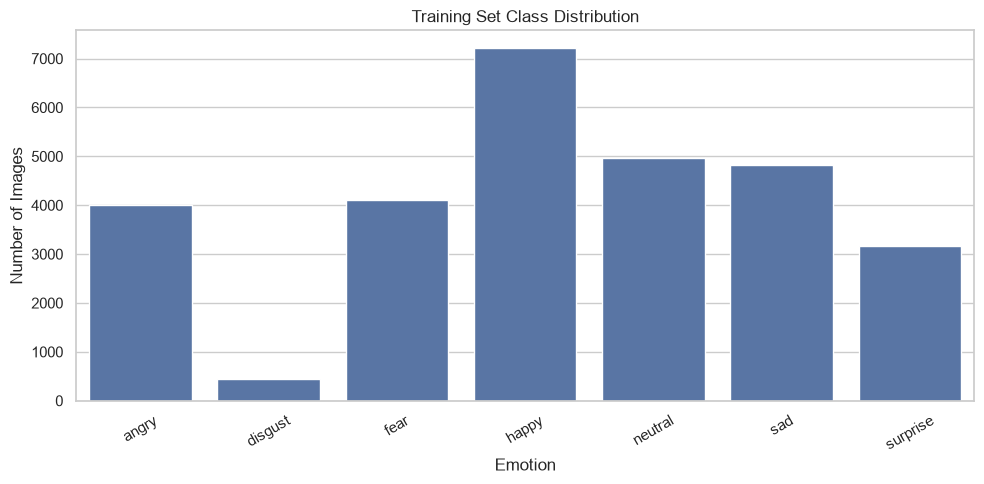

In [15]:
sns.barplot(
    data=train_distribution,
    x="Emotion",
    y="Number of Images",
)

plt.title("Training Set Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## Sample Images

This section displays a sample image for each facial expression class to provide an overview of the dataset.

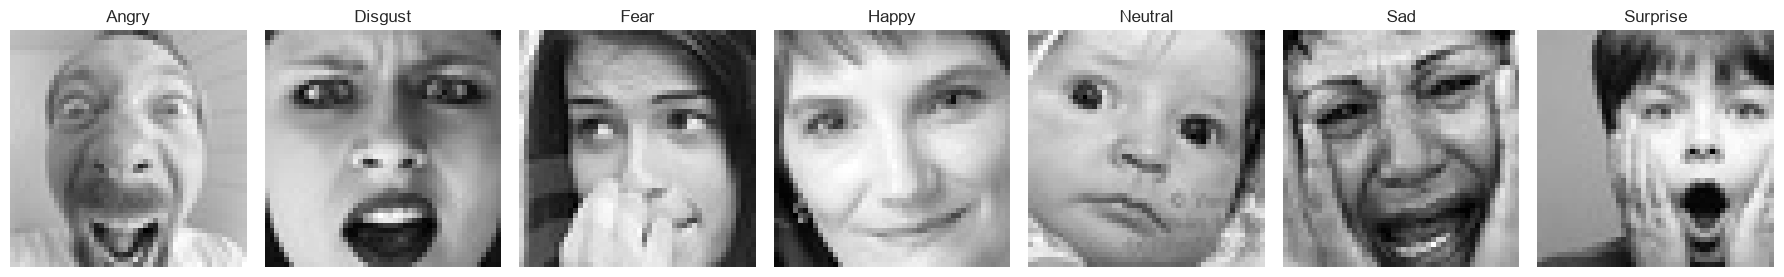

In [18]:
fig, axes = plt.subplots(1, len(classes), figsize=(18, 4))

for ax, emotion in zip(axes, classes):
    image_path = next((TRAIN_DIR / emotion).glob("*"))

    image = Image.open(image_path)

    ax.imshow(image, cmap="gray")
    ax.set_title(emotion.capitalize())
    ax.axis("off")

plt.tight_layout()
plt.show()

## Image Properties

This section analyzes the image dimensions and color channels to verify dataset consistency before training.

In [19]:
image_sizes = []
image_modes = []

for emotion in classes:
    for image_path in (TRAIN_DIR / emotion).glob("*"):
        image = Image.open(image_path)

        image_sizes.append(image.size)
        image_modes.append(image.mode)

In [20]:
sizes = pd.Series(image_sizes).value_counts()
modes = pd.Series(image_modes).value_counts()

display(sizes)
display(modes)

(48, 48)    28709
Name: count, dtype: int64

L    28709
Name: count, dtype: int64

### Observations

- All training images have a resolution of **48 × 48 pixels**.
- All images are stored in **grayscale** format (`L` mode).
- No inconsistencies in image dimensions or color channels were detected.
- The dataset is well-structured and suitable for the preprocessing stage.

In [21]:
corrupted_images = []

for emotion in classes:
    for image_path in (TRAIN_DIR / emotion).glob("*"):
        try:
            with Image.open(image_path) as image:
                image.verify()
        except Exception:
            corrupted_images.append(image_path)

print(f"Corrupted images found: {len(corrupted_images)}")

Corrupted images found: 0


### Data Quality Validation

No corrupted images were found in the training dataset. This confirms that the images can be safely used in the preprocessing and model training pipeline.